In [1]:
#!pip install kagglehub==1.0.0 -q

In [2]:
import os

path = None

if os.path.exists("../data/raw"):
    path = "../data/raw"
else:
    # login in a different cell to avoid a known kagglehub issue
    import kagglehub
    kagglehub.login()
    #KGAT_711ad5fd816c7a6fbb583a8baa9ecc15

In [3]:
if path is None:
    # do not forget to enter the Kaggle competition through the link in the project statement (section 4)
    path = kagglehub.competition_download('aca-tp-2')
    print("Path to dataset files:", path)

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [6]:
import sys

sys.path.append(os.path.abspath('..'))

from src.baseline.model import BaselineCNN
from src.utils.data_loader import ButterflyDataset

In [7]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [8]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


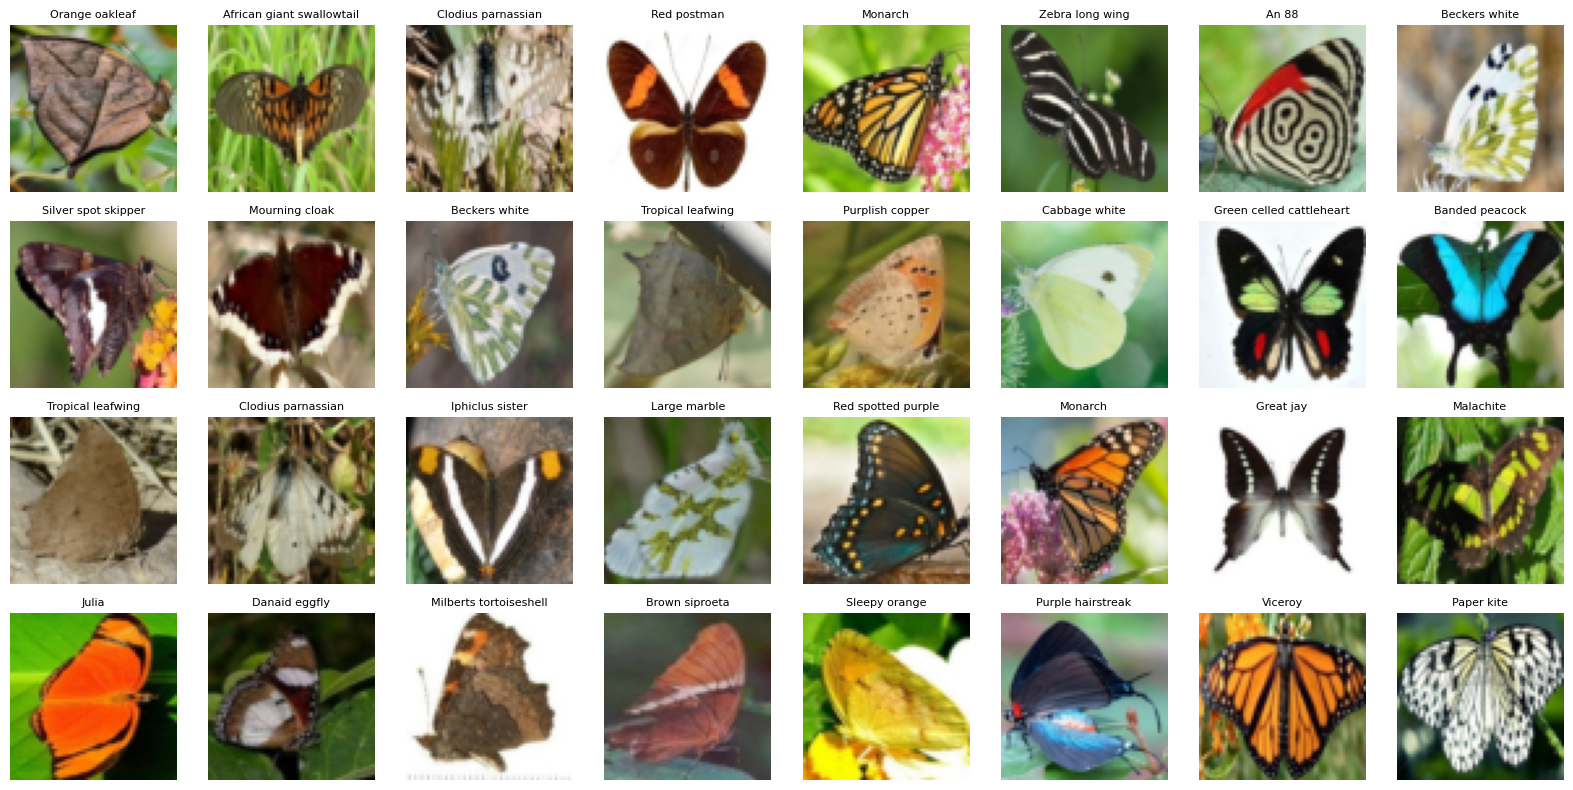

In [9]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Classifier

In [10]:
n_classes = len(dataset.classes)
model = BaselineCNN(num_classes=n_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [11]:
from src.baseline.train import train_model

In [13]:
import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.12.0+cpu
CUDA Available: False


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running experiment on: {device}")

train_model(dataloader, device=device)

Running experiment on: cpu


KeyboardInterrupt: 